# Walmart Sales Data Cleaning & Preprocessing

This notebook performs structured data cleaning and preprocessing on Walmart sales data.  
The cleaned dataset will be used for SQL-based business analysis and Power BI dashboard visualization.

### Objectives:
- Inspect dataset structure
- Handle duplicates and missing values
- Clean and standardize data types
- Perform basic exploratory analysis
- Export cleaned dataset for downstream analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
Reading raw Walmart sales dataset.

In [2]:
df=pd.read_csv("walmart.csv")
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


## Dataset Overview
Checking dataset dimensions and statistical summary.

In [3]:
df.shape

(10051, 11)

In [4]:
df.describe()

,invoice_id,quantity,rating,profit_margin
count,10051.000000,10020.000000,10051.000000,10051.000000
mean,5025.741220,2.353493,5.825659,0.393791
std,2901.174372,1.602658,1.763991,0.090669
min,1.000000,1.000000,3.000000,0.180000
25%,2513.500000,1.000000,4.000000,0.330000
50%,5026.000000,2.000000,6.000000,0.330000
75%,7538.500000,3.000000,7.000000,0.480000
max,10000.000000,10.000000,10.000000,0.570000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


## Handling Duplicate Records
Identifying and removing duplicate rows to ensure data integrity.

In [6]:
df.duplicated().sum()

np.int64(51)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(10000, 11)

## Handling Missing Values
Checking for null values across columns.

In [9]:
df.isnull().sum()

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(9969, 11)

## Data Type Cleaning
Cleaning and converting columns to appropriate data types.

In [12]:
df["date"].head(20)

0     05/01/19
1     08/03/19
2     03/03/19
3     27/01/19
4     08/02/19
5     25/03/19
6     25/02/19
7     24/02/19
8     10/01/19
9     20/02/19
10    06/02/19
11    09/03/19
12    12/02/19
13    07/02/19
14    29/03/19
15    15/01/19
16    11/03/19
17    01/01/19
18    21/01/19
19    11/03/19
Name: date, dtype: object

In [13]:
# Remove $ and convert unit_price to float
df["unit_price"] = df["unit_price"].str.replace("$", "", regex=False).astype(float)

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df.info()

C:\Users\skt\AppData\Local\Temp\ipykernel_15340\2368971220.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True)


<class 'pandas.core.frame.DataFrame'>
Index: 9969 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_id      9969 non-null   int64         
 1   Branch          9969 non-null   object        
 2   City            9969 non-null   object        
 3   category        9969 non-null   object        
 4   unit_price      9969 non-null   float64       
 5   quantity        9969 non-null   float64       
 6   date            9969 non-null   datetime64[ns]
 7   time            9969 non-null   object        
 8   payment_method  9969 non-null   object        
 9   rating          9969 non-null   float64       
 10  profit_margin   9969 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 934.6+ KB


## Feature Engineering
Creating derived features for analysis.

In [14]:
df["total"] = df["unit_price"] * df["quantity"]
df["year"] = df["date"].dt.year

In [15]:
df["year"].value_counts().sort_index()

year
2019    1000
2020    2211
2021    2303
2022    2228
2023    2227
Name: count, dtype: int64

In [16]:
df.columns = df.columns.str.lower()
df.columns

Index(['invoice_id', 'branch', 'city', 'category', 'unit_price', 'quantity',
       'date', 'time', 'payment_method', 'rating', 'profit_margin', 'total',
       'year'],
      dtype='object')

In [17]:
df.isnull().sum()

invoice_id        0
branch            0
city              0
category          0
unit_price        0
quantity          0
date              0
time              0
payment_method    0
rating            0
profit_margin     0
total             0
year              0
dtype: int64

## Exploratory Data Analysis
Understanding category distribution and revenue trends.

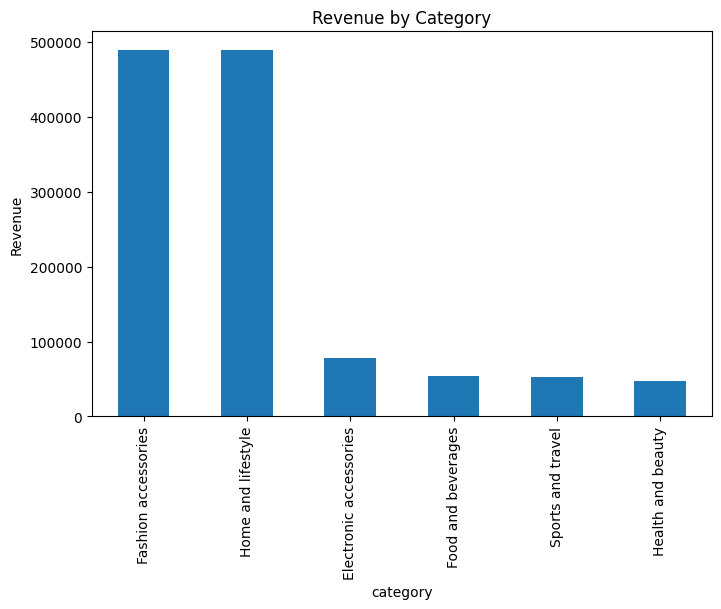

In [18]:
df.groupby("category")["total"].sum().sort_values(ascending=False).plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

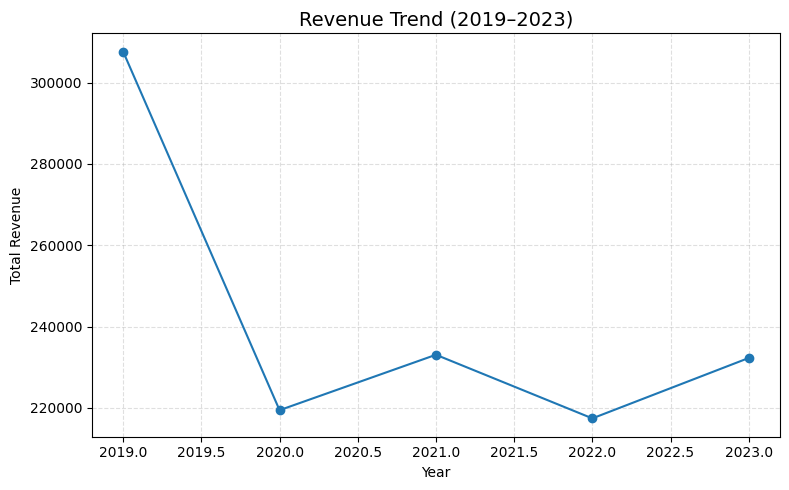

In [19]:
df.groupby("year")["total"].sum().plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Revenue Trend (2019–2023)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Exporting Cleaned Dataset
Saving processed data for SQL analysis and dashboard creation.

In [20]:
df.to_csv("cleaned_walmart.csv", index=False)